# Fair and Efficient Task Allocation and Path Planning for Multi-Agent Systems in Disaster Response Using Linear Programming

**Author:** Trung Hieu Pham (Jack Pham)  
**Advisors:** Dr. Adam Thorpe (Center for Autonomy, UT Austin), Dr. Ufuk Topcu (Dept. of Aerospace Engineering & Engineering Mechanics, UT Austin)  
**Institution:** Cypress College / University of Texas at Austin  
**Funding:** NSF REU Site: CI Research 4 Social Change, Award #2150390

---

## Overview

This notebook recreates and explains the full research pipeline from the paper:

1. **Background & Motivation** — Why fairness matters in disaster response
2. **MDP Formulation** — State, action, reward, policy, discount factor
3. **Fairness Theory** — The FE-MADDPG reward function
4. **LP Task Allocation** — Linear programming for fair, efficient assignment
5. **CBS Pathfinding** — Conflict-Based Search for collision-free navigation
6. **Algorithm Comparison** — Switch between Greedy, CBS, LP+CBS, LP+CBS+FE-MADDPG
7. **Replication of Paper Figures** — Fig 1, 2, 3 from the original poster
8. **Multi-Episode Experiment** — Statistical performance over 100 episodes


In [4]:
# Pull files directly from GitHub
!wget -q https://raw.githubusercontent.com/jackpham-rgb/area-disaster-response/main/disaster_response_sim.py

print(" Module downloaded!")

 Module downloaded!


---
## 1. Setup & Imports

In [5]:
# Install dependencies if needed
import subprocess, sys
for pkg in ['scipy', 'matplotlib', 'numpy']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

import sys, os
sys.path.insert(0, '.')  # ensure local module is found

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Import our simulation module
from disaster_response_sim import (
    DisasterEnv, run_lp_cbs, run_greedy, run_cbs_only,
    run_experiment, compare_algorithms,
    plot_grid, plot_task_allocation, plot_solve_times, plot_fairness_comparison,
    lp_task_allocation, greedy_task_allocation, fe_maddpg_adjust_assignment,
    cbs, astar
)

print('All imports successful!')
print('Simulation module loaded from: disaster_response_sim.py')

All imports successful!
Simulation module loaded from: disaster_response_sim.py


---
## 2. Background & Motivation

### Why Disaster Response?

As disaster frequency and severity increase globally — earthquakes, wildfires, floods — **multi-robot systems** become critical for:
- 🔍 Search and rescue operations
- 🔥 Fire suppression
- 📦 Resource delivery

Traditional approaches optimize for **efficiency only** (minimize completion time), but this creates **fairness problems**:
- Some robots are overloaded → bottlenecks
- Other robots sit idle → wasted capacity
- Inequitable service delivery → public trust issues

### The Core Research Problem

> How can we allocate tasks and plan collision-free paths for multiple robots such that the system is **both efficient AND fair**?

### Key Reference
The problem is inspired by real-world disaster data, including:
- Rashmin et al. (2023). *Global Rapid Post-Disaster Damage Estimation (GRADE) Report: February 6, 2023 Kahramanmaraş Earthquakes.* World Bank. https://doi.org/10.1596/39468

---
### Application Domains

| Domain | Use Case |
|---|---|
| Disaster Response | Search & rescue, fire suppression |
| Urban Air Mobility | Drone delivery fairness |
| Warehouse Automation | Fair robot workload distribution |
| Agriculture | Multi-robot crop management |

---
## 3. MDP Formulation

We model the problem as a **Markov Decision Process (MDP)** — the standard framework for sequential decision-making under uncertainty.

An MDP is defined by the 5-tuple **(S, A, R, π, γ)**:

| Symbol | Name | Description |
|---|---|---|
| **S** | State | Grid snapshot: agent positions, fire locations, obstacle positions, task completion status |
| **A** | Action | Movement decisions for each agent: UP, DOWN, LEFT, RIGHT, WAIT |
| **R** | Reward | Fairness-aware reward signal (see Section 4) |
| **π** | Policy | Function mapping states → actions (determined by LP + FE-MADDPG) |
| **γ** | Discount Factor | γ ∈ [0,1], emphasizes long-term benefits in path planning |

**Reference:** Zhang et al. (2017). *Battlefield agent decision-making based on Markov decision process.* JACIII, 21(2), 221–227. https://doi.org/10.20965/jaciii.2017.p0221

In [6]:
# ─── Configuration Panel ───────────────────────────────────────────────────
# Change these parameters to explore different scenarios!

SEED        = 42     # 🌱 Pseudo-random seed — same seed = same world every run
GRID_SIZE   = 10     # Grid dimensions (GRID_SIZE x GRID_SIZE)
N_AGENTS    = 5      # Number of robots
N_TASKS     = 10     # Number of fire tasks
N_OBSTACLES = 10     # Number of wall obstacles
GAMMA       = 0.95   # Discount factor
EPSILON     = 1e-6   # Numerical stability constant ε

# Create environment
env = DisasterEnv(
    grid_size=GRID_SIZE,
    n_agents=N_AGENTS,
    n_tasks=N_TASKS,
    n_obstacles=N_OBSTACLES,
    seed=SEED,
    epsilon=EPSILON,
    gamma=GAMMA
)

print(f'🌍 Environment created with seed={SEED}')
print(f'   Grid: {GRID_SIZE}×{GRID_SIZE}')
print(f'   Agents: {N_AGENTS}   Tasks: {N_TASKS}   Obstacles: {N_OBSTACLES}')
print(f'   γ (discount): {GAMMA}   ε (stability): {EPSILON}')

print('\nAgent starting positions:')
for a in env.agents:
    print(f'  Agent {a.id}: row={a.position[0]}, col={a.position[1]}')

print('\nFire task positions:')
for t in env.tasks:
    print(f'  Task {t.id}: row={t.position[0]}, col={t.position[1]}')

🌍 Environment created with seed=42
   Grid: 10×10
   Agents: 5   Tasks: 10   Obstacles: 10
   γ (discount): 0.95   ε (stability): 1e-06

Agent starting positions:
  Agent 0: row=1, col=9
  Agent 1: row=7, col=6
  Agent 2: row=5, col=4
  Agent 3: row=4, col=2
  Agent 4: row=0, col=5

Fire task positions:
  Task 0: row=8, col=0
  Task 1: row=8, col=8
  Task 2: row=2, col=6
  Task 3: row=1, col=7
  Task 4: row=7, col=3
  Task 5: row=0, col=9
  Task 6: row=6, col=7
  Task 7: row=7, col=1
  Task 8: row=3, col=4
  Task 9: row=4, col=0


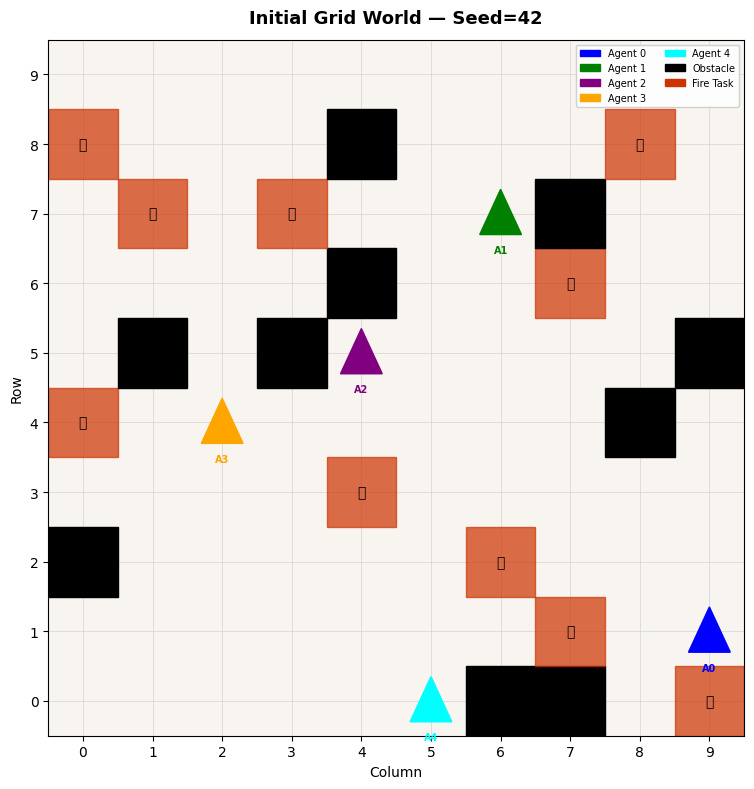

Saved: fig1_grid_world.png


In [7]:
# Visualize the initial grid world (Figure 1 style)
fig, ax = plt.subplots(figsize=(8, 8))
plot_grid(env, paths=None, title=f'Initial Grid World — Seed={SEED}', ax=ax)
plt.tight_layout()
plt.savefig('fig1_grid_world.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_grid_world.png')

---
## 4. Fairness Theory — The FE-MADDPG Reward Function

### What is FE-MADDPG?

**Fairness-Enhanced Multi-Agent Deep Deterministic Policy Gradient** extends the standard MADDPG reinforcement learning framework with a **fairness reward signal**.

**Reference:** Liu et al. (2022). *A fairness-aware cooperation strategy for multi-agent systems driven by Deep Reinforcement Learning.* 41st Chinese Control Conference (CCC). https://doi.org/10.23919/ccc55666.2022.9902130

### The Fairness Reward Function

$$r_t^i = \frac{\varepsilon + \left|\frac{e_t^i}{\bar{e}_t} - 1\right|}{\bar{e}_t}$$

Where:
- $r_t^i$ — reward for agent $i$ at time $t$
- $\varepsilon$ — small constant to prevent division by zero (numerical stability)
- $e_t^i$ — performance of agent $i$ (inverse distance to assigned task)
- $\bar{e}_t$ — **average** performance across all $n$ agents at time $t$

### Intuition

The term $\left|\frac{e_t^i}{\bar{e}_t} - 1\right|$ measures **how far agent $i$'s performance deviates from the average**.

- If all agents perform equally → all deviations = 0 → **low fairness penalty**
- If one agent is far overloaded → large deviation → **high fairness penalty**

The policy learns to **equalize performance** across agents over time.

In [8]:
# ─── Demonstrate the fairness reward function ─────────────────────────────

print('=== Fairness Reward Demonstration ===')
print(f'ε = {env.epsilon}')
print()

# Scenario 1: Equal task loads (ideal fairness)
equal_perfs = [0.5, 0.5, 0.5, 0.5, 0.5]
print('Scenario 1: Equal performance (ideal)')
for i, p in enumerate(equal_perfs):
    r = env.fairness_reward(i, equal_perfs)
    print(f'  Agent {i}: e_i={p:.2f}, reward r_t^i = {r:.6f}')

print()

# Scenario 2: Unequal task loads (unfair — one overloaded)
unequal_perfs = [0.1, 0.5, 0.5, 0.5, 0.9]
print('Scenario 2: Unequal performance (unfair)')
for i, p in enumerate(unequal_perfs):
    r = env.fairness_reward(i, unequal_perfs)
    print(f'  Agent {i}: e_i={p:.2f}, reward r_t^i = {r:.6f}')

print()
print('Observation: Higher reward = more deviation from average = less fair.')
print('FE-MADDPG trains agents to MINIMIZE this reward (achieve equality).')

=== Fairness Reward Demonstration ===
ε = 1e-06

Scenario 1: Equal performance (ideal)
  Agent 0: e_i=0.50, reward r_t^i = 0.000002
  Agent 1: e_i=0.50, reward r_t^i = 0.000002
  Agent 2: e_i=0.50, reward r_t^i = 0.000002
  Agent 3: e_i=0.50, reward r_t^i = 0.000002
  Agent 4: e_i=0.50, reward r_t^i = 0.000002

Scenario 2: Unequal performance (unfair)
  Agent 0: e_i=0.10, reward r_t^i = 1.600002
  Agent 1: e_i=0.50, reward r_t^i = 0.000002
  Agent 2: e_i=0.50, reward r_t^i = 0.000002
  Agent 3: e_i=0.50, reward r_t^i = 0.000002
  Agent 4: e_i=0.90, reward r_t^i = 1.600002

Observation: Higher reward = more deviation from average = less fair.
FE-MADDPG trains agents to MINIMIZE this reward (achieve equality).


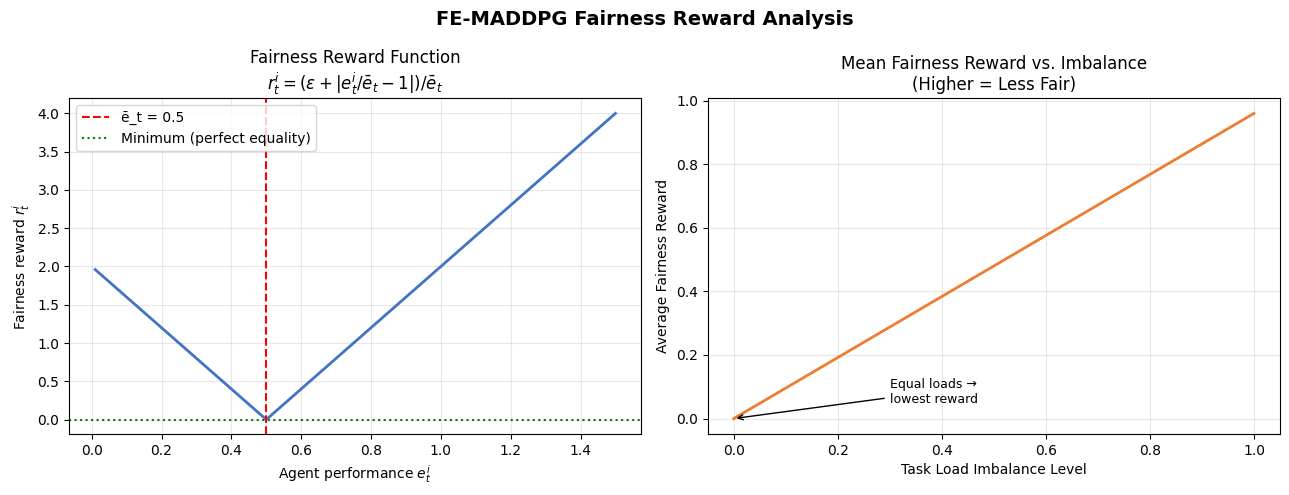

In [9]:
# ─── Visualize fairness reward surface ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: reward vs e_i (varying one agent's performance)
e_bar = 0.5
eps   = 1e-6
e_vals = np.linspace(0.01, 1.5, 200)
rewards = [(eps + abs(e/e_bar - 1)) / e_bar for e in e_vals]

axes[0].plot(e_vals, rewards, color='#4472C4', linewidth=2)
axes[0].axvline(x=e_bar, color='red', linestyle='--', label=f'ē_t = {e_bar}')
axes[0].axhline(y=eps/e_bar, color='green', linestyle=':', label='Minimum (perfect equality)')
axes[0].set_xlabel('Agent performance $e_t^i$')
axes[0].set_ylabel('Fairness reward $r_t^i$')
axes[0].set_title('Fairness Reward Function\n$r_t^i = (\\varepsilon + |e_t^i/\\bar{e}_t - 1|) / \\bar{e}_t$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: reward for 5 agents at different imbalance levels
imbalance = np.linspace(0, 1.0, 50)
agent_rewards = []
for imb in imbalance:
    # Spread performances from equal to very unequal
    perfs = [0.5 - imb*0.4, 0.5 - imb*0.2, 0.5, 0.5 + imb*0.2, 0.5 + imb*0.4]
    e_b   = np.mean(perfs)
    rewards_i = [(eps + abs(e/e_b - 1)) / e_b for e in perfs]
    agent_rewards.append(np.mean(rewards_i))

axes[1].plot(imbalance, agent_rewards, color='#ED7D31', linewidth=2)
axes[1].set_xlabel('Task Load Imbalance Level')
axes[1].set_ylabel('Average Fairness Reward')
axes[1].set_title('Mean Fairness Reward vs. Imbalance\n(Higher = Less Fair)')
axes[1].grid(True, alpha=0.3)
axes[1].annotate('Equal loads →\nlowest reward', xy=(0, agent_rewards[0]),
                  xytext=(0.3, agent_rewards[0]+0.05),
                  arrowprops=dict(arrowstyle='->', color='black'),
                  fontsize=9)

plt.suptitle('FE-MADDPG Fairness Reward Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fairness_reward.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. LP Task Allocation

### Linear Programming Formulation

**Objective Function** — Minimize total travel cost:
$$\min \sum_{i=1}^{n} \sum_{j=1}^{m} c_{ij} \cdot x_{ij}$$

Where:
- $c_{ij}$ = Manhattan distance cost for robot $i$ to perform task $j$
- $x_{ij} \in \{0, 1\}$ = binary assignment variable

**Fairness Constraint** — Minimize maximum discrepancy:
$$\min \max_i \left| x_i - \frac{1}{n} \sum_{j=1}^{n} x_j \right|$$

**Hard Constraints:**
1. Each task assigned to exactly one agent: $\sum_i x_{ij} = 1 \quad \forall j$
2. Workload balanced as evenly as possible (max tasks per agent bounded)

**Comparison with Greedy:**
- Greedy: assign each task to nearest agent → fast but **ignores fairness**
- LP: optimize globally → slightly slower but **guarantees fairness**

In [10]:
# ─── Run LP vs Greedy allocation on same environment ─────────────────────

env_demo = DisasterEnv(grid_size=GRID_SIZE, n_agents=N_AGENTS,
                        n_tasks=N_TASKS, n_obstacles=N_OBSTACLES, seed=SEED)

# Greedy allocation (baseline — no fairness)
greedy_assign = greedy_task_allocation(env_demo)
greedy_loads  = [len(greedy_assign[a.id]) for a in env_demo.agents]

# LP allocation (efficient + fair)
lp_assign = lp_task_allocation(env_demo)
lp_loads  = [len(lp_assign[a.id]) for a in env_demo.agents]

# FE-MADDPG adjustment on top of LP
fe_assign = fe_maddpg_adjust_assignment(env_demo, lp_assign)
fe_loads  = [len(fe_assign[a.id]) for a in env_demo.agents]

print('Task load distribution per algorithm:')
print(f'{"Agent":<10} {"Greedy":>8} {"LP":>8} {"LP+FE":>8}')
print('-' * 38)
for i, a in enumerate(env_demo.agents):
    print(f'{"Agent "+str(i):<10} {greedy_loads[i]:>8} {lp_loads[i]:>8} {fe_loads[i]:>8}')

print(f'\nVariance →  Greedy: {np.var(greedy_loads):.3f}  |  LP: {np.var(lp_loads):.3f}  |  LP+FE: {np.var(fe_loads):.3f}')
print(f'Std Dev  →  Greedy: {np.std(greedy_loads):.3f}  |  LP: {np.std(lp_loads):.3f}  |  LP+FE: {np.std(fe_loads):.3f}')

Task load distribution per algorithm:
Agent        Greedy       LP    LP+FE
--------------------------------------
Agent 0           2        2        2
Agent 1           3        3        2
Agent 2           1        1        2
Agent 3           3        3        2
Agent 4           1        1        2

Variance →  Greedy: 0.800  |  LP: 0.800  |  LP+FE: 0.000
Std Dev  →  Greedy: 0.894  |  LP: 0.894  |  LP+FE: 0.000


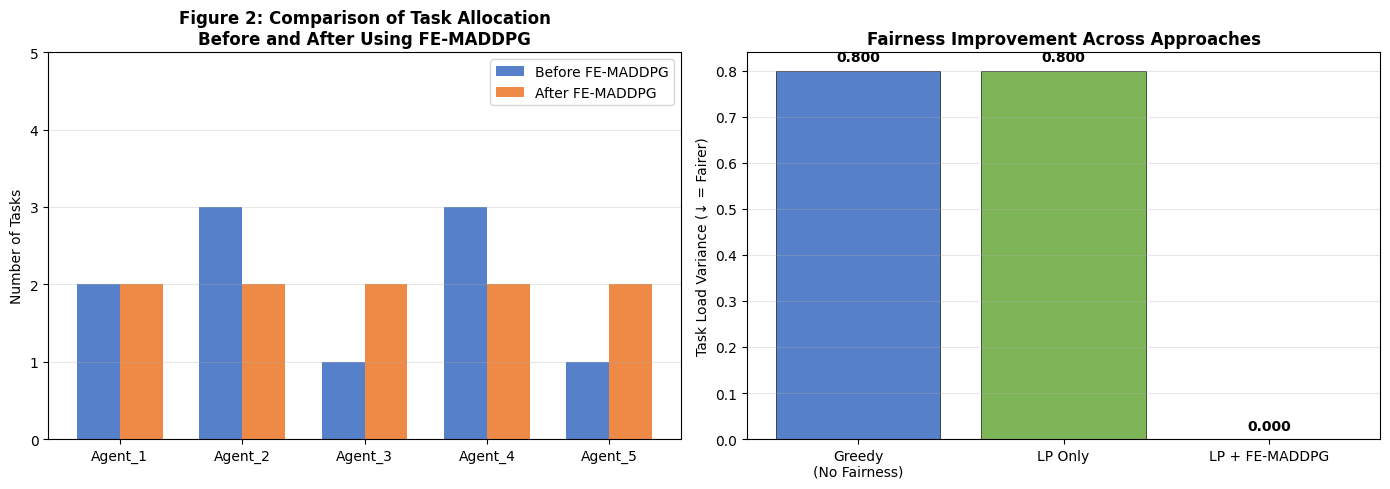

Saved: fig2_task_allocation.png


In [11]:
# ─── Reproduce Paper Figure 2: Task Allocation Before/After FE-MADDPG ────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before vs After FE-MADDPG
n = N_AGENTS
x = np.arange(n)
w = 0.35

axes[0].bar(x - w/2, greedy_loads, w, label='Before FE-MADDPG', color='#4472C4', alpha=0.9)
axes[0].bar(x + w/2, fe_loads,     w, label='After FE-MADDPG',  color='#ED7D31', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Agent_{i+1}' for i in range(n)])
axes[0].set_ylabel('Number of Tasks')
axes[0].set_title('Figure 2: Comparison of Task Allocation\nBefore and After Using FE-MADDPG', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, max(max(greedy_loads), max(fe_loads)) + 2)
axes[0].grid(axis='y', alpha=0.3)

# Fairness comparison bar
algorithms = ['Greedy\n(No Fairness)', 'LP Only', 'LP + FE-MADDPG']
variances  = [np.var(greedy_loads), np.var(lp_loads), np.var(fe_loads)]
colors     = ['#4472C4', '#70AD47', '#ED7D31']

axes[1].bar(algorithms, variances, color=colors, alpha=0.9, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Task Load Variance (↓ = Fairer)')
axes[1].set_title('Fairness Improvement Across Approaches', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(variances):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_task_allocation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_task_allocation.png')

---
## 6. CBS Pathfinding — Conflict-Based Search

### Algorithm Overview

**CBS** finds collision-free paths for all agents simultaneously.

**Reference:** Huang et al. (2021). *Learning to resolve conflicts for multi-agent path finding with conflict-based search.* AAAI, 35(13), 11246–11253. https://doi.org/10.1609/aaai.v35i13.17341

### Two-Level Architecture

**High Level — Constraint Tree:**
- Maintains a tree of constraints (agent $i$ cannot be at position $p$ at time $t$)
- At each node: check for conflicts, split into two child nodes (one constraint per agent)
- Uses best-first search (lowest total path cost)

**Low Level — A\* with Constraints:**
- For each agent, finds shortest path given its current constraint set
- Space-time A\*: state = (position, timestep)

### CBS Algorithm (pseudocode from paper)
```
Input:  Initial paths for all agents
Output: Collision-free paths

1: Initialize open list with root node (start paths, no constraints)
2: While open list is not empty:
3:   Pop node with lowest cost
4:   Check for conflicts between all agent paths
5:   If conflict detected:
       Create two child nodes with additional constraints
       Push children to open list
6:   If no conflicts → return paths ✓
```

### LP Integration with CBS

LP is integrated into CBS to minimize path cost while satisfying dynamic constraints:

$$\min \sum_{i=1}^{n} \sum_{j=1}^{m} c_{ij} x_{ij}$$

**Constraint functions:**
- **Collision Avoidance:** $X_i + X_j \leq 1$ if paths $i$ and $j$ intersect
- **Task Completion:** $\sum_i X_i(t) = 1$ for each task $t$
- **Feasibility:** $X_i \in \{0, 1\}$

In [12]:
# ─── Run CBS and visualize paths ──────────────────────────────────────────

env_vis = DisasterEnv(grid_size=GRID_SIZE, n_agents=N_AGENTS,
                       n_tasks=N_TASKS, n_obstacles=N_OBSTACLES, seed=SEED)

# Run full LP + FE-MADDPG + CBS
result_lp = run_lp_cbs(env_vis, use_fe_maddpg=True)

print('LP + FE-MADDPG + CBS Results:')
print(f'  Solve time:     {result_lp["solve_time_s"]*1000:.2f} ms')
print(f'  Makespan:       {result_lp["max_makespan"]} steps')
print(f'  Total path len: {result_lp["total_path_len"]} steps')
print(f'  Gini coeff:     {result_lp["gini"]:.4f} (0=perfect equality)')
print(f'  Load variance:  {result_lp["load_variance"]:.4f}')
print(f'  Task loads:     {result_lp["task_loads"]}')

LP + FE-MADDPG + CBS Results:
  Solve time:     6.47 ms
  Makespan:       10 steps
  Total path len: 29 steps
  Gini coeff:     0.0000 (0=perfect equality)
  Load variance:  0.0000
  Task loads:     [2, 2, 2, 2, 2]


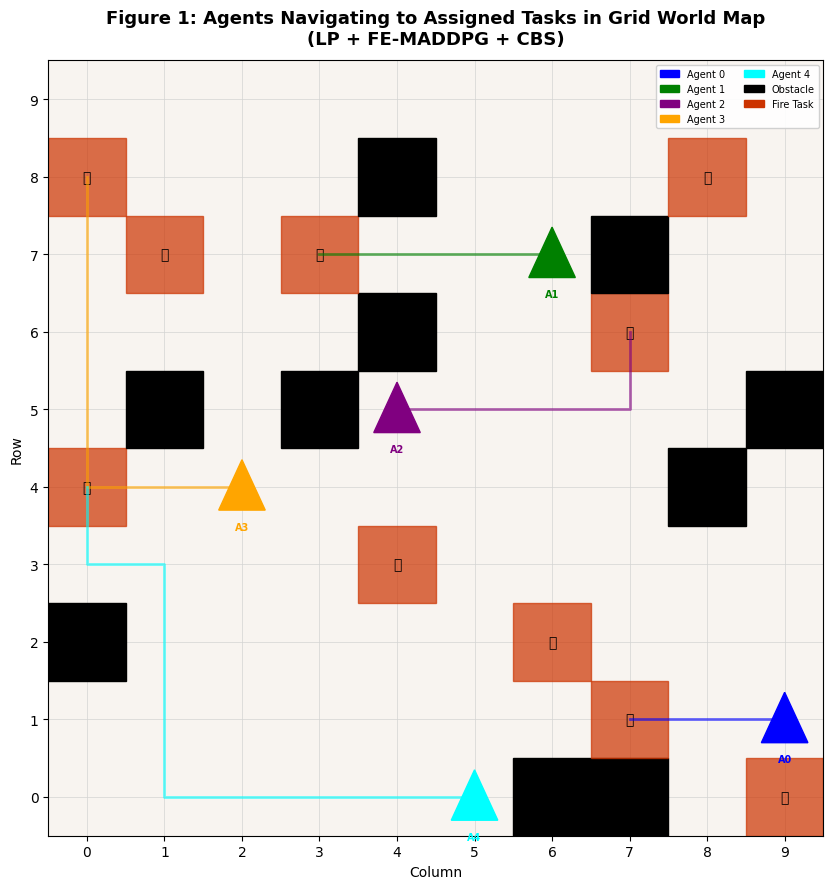

Saved: fig1_agents_navigating.png


In [13]:
# ─── Figure 1 replica: Grid with agent paths ──────────────────────────────

fig, ax = plt.subplots(figsize=(9, 9))
plot_grid(env_vis,
           paths=result_lp['paths'],
           title='Figure 1: Agents Navigating to Assigned Tasks in Grid World Map\n(LP + FE-MADDPG + CBS)',
           ax=ax)
plt.tight_layout()
plt.savefig('fig1_agents_navigating.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_agents_navigating.png')

---
## 7. Algorithm Comparison — Switch Between Methods

This section lets you **interactively compare** all algorithms on the same environment.

| Algorithm | Task Allocation | Pathfinding | Fairness |
|---|---|---|---|
| **Greedy** | Nearest-agent | A\* (no conflict resolution) | ❌ None |
| **CBS Only** | Greedy | CBS (conflict-free) | ❌ None |
| **LP + CBS** | LP-optimized | CBS | ⚠️ Partial |
| **LP + CBS + FE-MADDPG** | LP + fairness adjusted | CBS | ✅ Full |

In [14]:
# ─── Run all 4 algorithms on the SAME environment ─────────────────────────
# (same seed = same world = fair comparison)

print('Running all algorithms on seed=%d environment...' % SEED)
print('(This may take 10-30 seconds for CBS)\n')

all_results = compare_algorithms(
    seed=SEED,
    grid_size=GRID_SIZE,
    n_agents=N_AGENTS,
    n_tasks=N_TASKS,
    n_obstacles=N_OBSTACLES
)

# Summary table
print(f'{"Algorithm":<22} {"Gini":>8} {"Variance":>10} {"Makespan":>10} {"Avg Path":>10} {"Time (ms)":>10}')
print('─' * 72)
for algo, r in all_results.items():
    print(f'{algo:<22} {r["gini"]:>8.4f} {r["load_variance"]:>10.4f} '
          f'{r["max_makespan"]:>10d} {r["avg_path_len"]:>10.1f} '
          f'{r["solve_time_s"]*1000:>10.2f}')

Running all algorithms on seed=42 environment...
(This may take 10-30 seconds for CBS)

Algorithm                  Gini   Variance   Makespan   Avg Path  Time (ms)
────────────────────────────────────────────────────────────────────────
Greedy                   0.2400     0.8000         12        6.6       2.46
CBS_only                 0.2400     0.8000          5        3.8       0.34
LP_CBS                   0.2400     0.8000          5        3.8       3.14
LP_CBS_FE                0.0000     0.0000         10        5.8       4.20


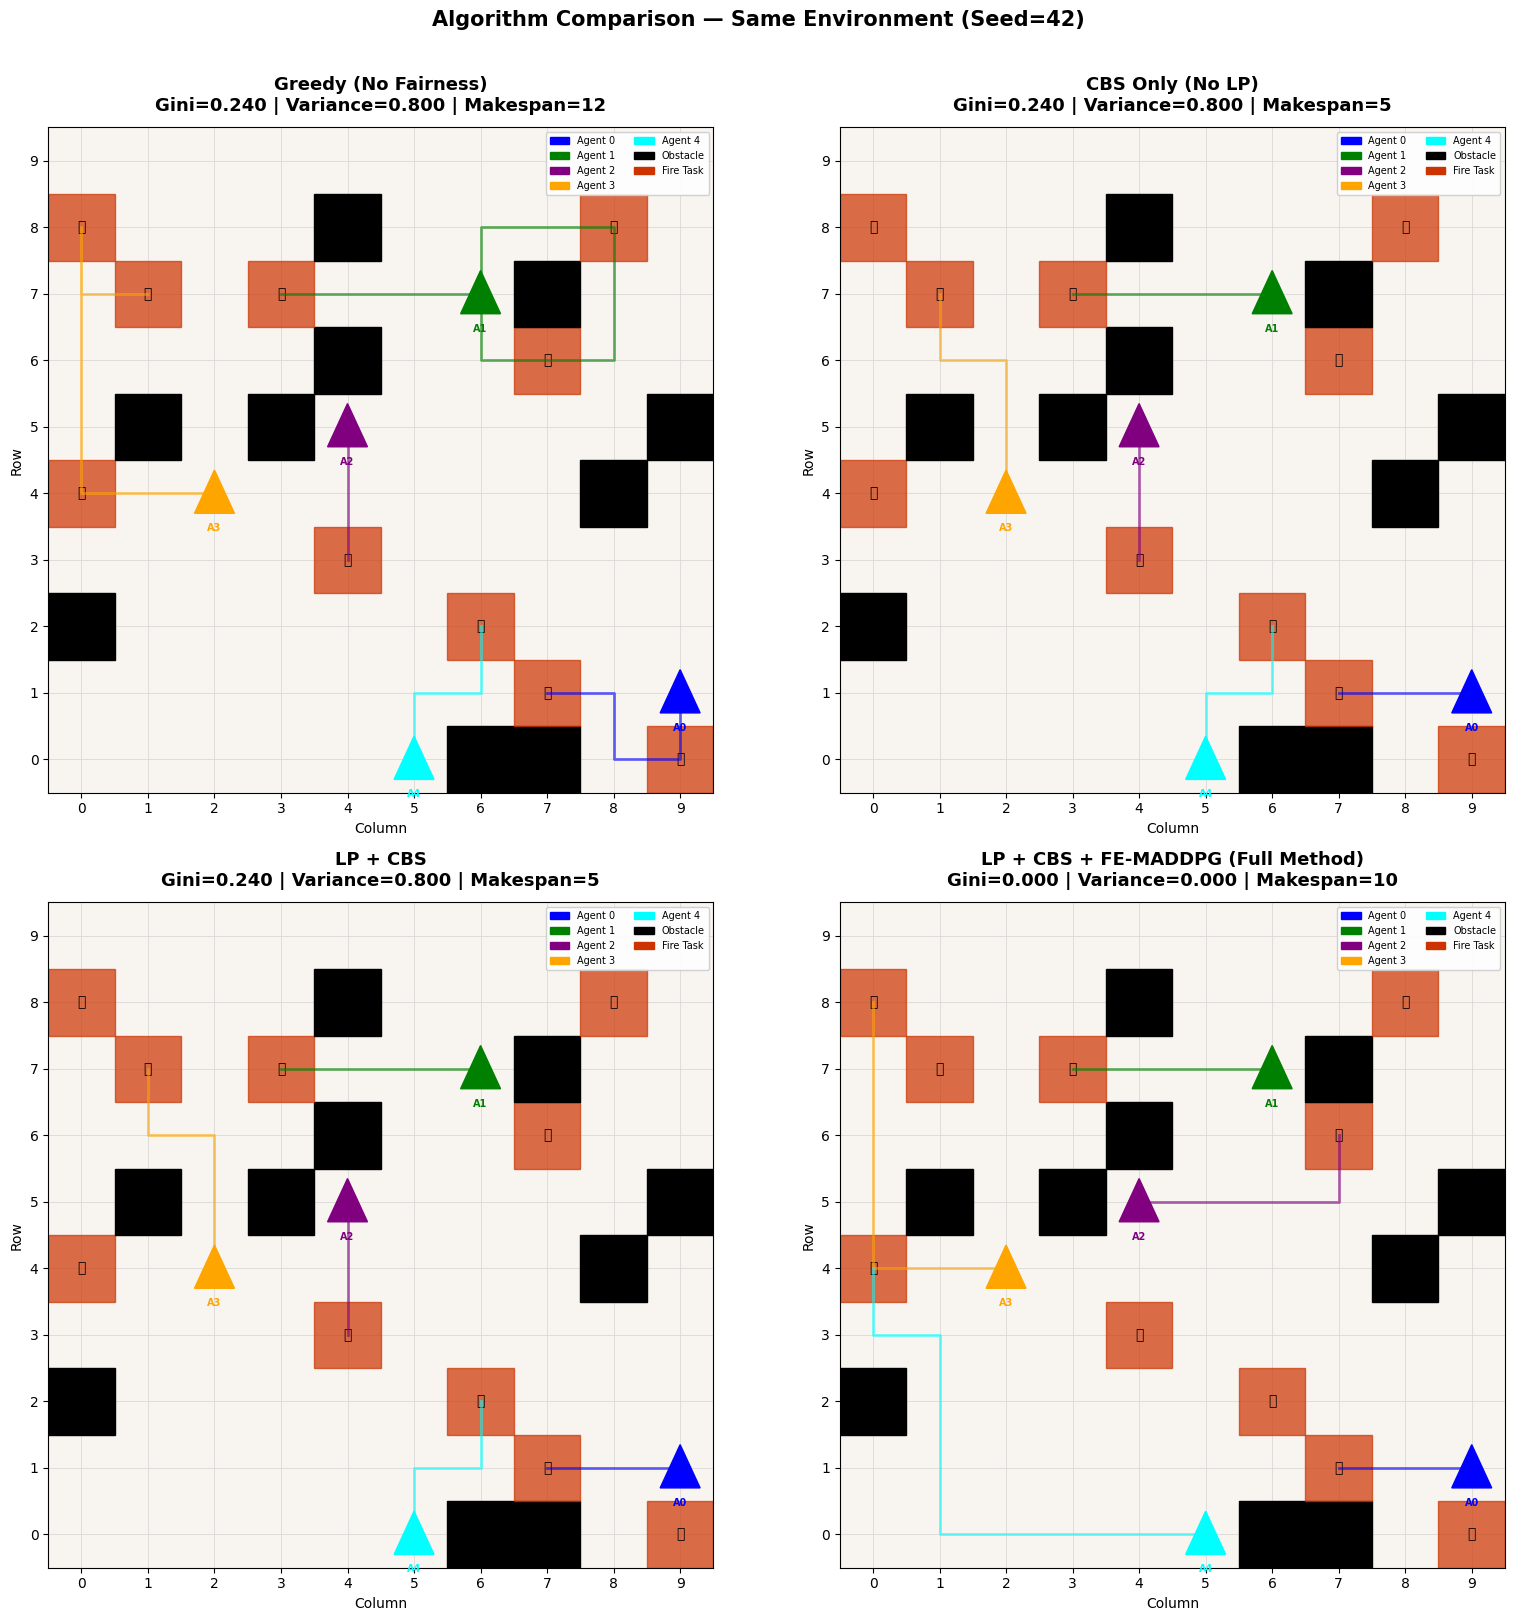

Saved: fig_algorithm_comparison.png


In [15]:
# ─── Side-by-side grid visualization ─────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
algo_keys = ['Greedy', 'CBS_only', 'LP_CBS', 'LP_CBS_FE']
titles    = ['Greedy (No Fairness)', 'CBS Only (No LP)',
              'LP + CBS', 'LP + CBS + FE-MADDPG (Full Method)']

for ax, key, title in zip(axes.flat, algo_keys, titles):
    env_tmp = DisasterEnv(grid_size=GRID_SIZE, n_agents=N_AGENTS,
                           n_tasks=N_TASKS, n_obstacles=N_OBSTACLES, seed=SEED)
    r = all_results[key]
    subtitle = f'Gini={r["gini"]:.3f} | Variance={r["load_variance"]:.3f} | Makespan={r["max_makespan"]}'
    plot_grid(env_tmp, paths=r['paths'], title=f'{title}\n{subtitle}', ax=ax)

plt.suptitle('Algorithm Comparison — Same Environment (Seed=%d)' % SEED,
              fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_algorithm_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: fig_algorithm_comparison.png')

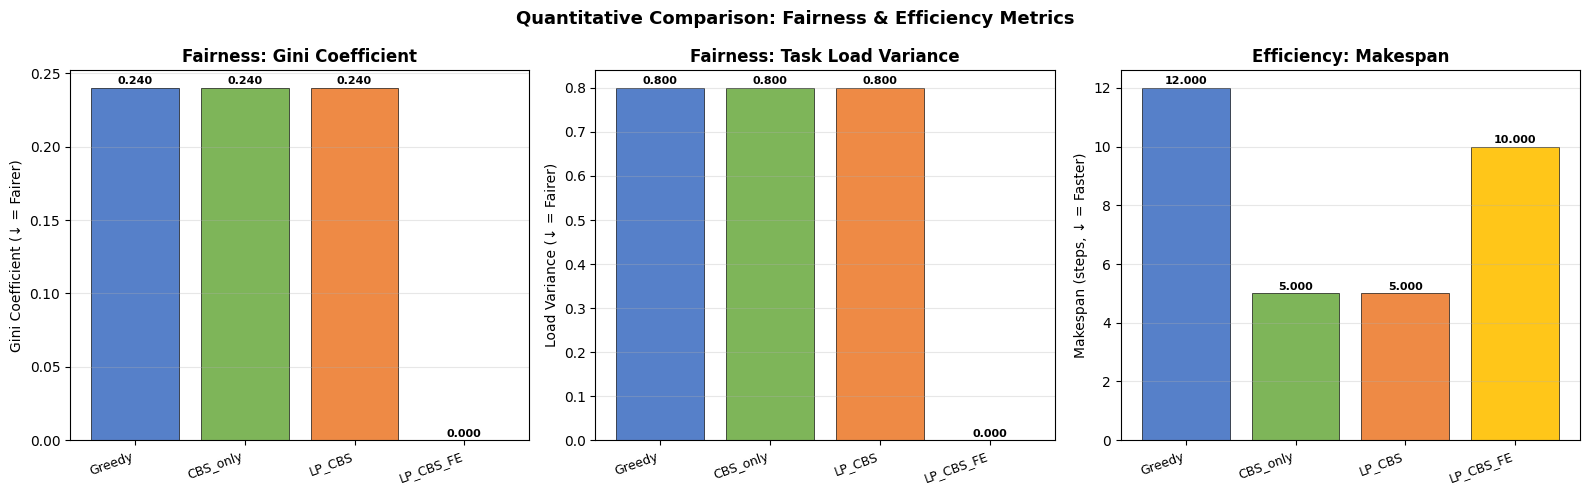

In [16]:
# ─── Fairness metrics comparison ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

algo_names   = list(all_results.keys())
ginis        = [all_results[a]['gini']          for a in algo_names]
variances    = [all_results[a]['load_variance']  for a in algo_names]
makespans    = [all_results[a]['max_makespan']   for a in algo_names]
colors       = ['#4472C4', '#70AD47', '#ED7D31', '#FFC000']

for ax, vals, ylabel, title in zip(
    axes,
    [ginis, variances, makespans],
    ['Gini Coefficient (↓ = Fairer)', 'Load Variance (↓ = Fairer)', 'Makespan (steps, ↓ = Faster)'],
    ['Fairness: Gini Coefficient', 'Fairness: Task Load Variance', 'Efficiency: Makespan']
):
    bars = ax.bar(range(len(algo_names)), vals, color=colors, alpha=0.9,
                   edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(algo_names)))
    ax.set_xticklabels(algo_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Quantitative Comparison: Fairness & Efficiency Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Multi-Episode Experiment — Replicating Paper Figure 3

The paper shows that the LP approach **consistently outperforms** non-LP methods in average solve time across 100 episodes.

Each episode uses a **different pseudo-random seed** (base_seed + episode_number), ensuring varied environments while being fully reproducible.

**Key observation from paper:**
> "The LP approach consistently outperforms the non-LP approach in terms of average time required to solve the maze across episodes, showing rapid stabilization and lower variation in solve times."

In [17]:
# ─── Multi-episode experiment (reproduces paper Fig 3) ────────────────────
# ⚠️  Reduce N_EPISODES for speed. Paper uses 100.

N_EPISODES  = 50    # ← change to 100 to fully replicate paper
BASE_SEED   = 42

print(f'Running {N_EPISODES} episodes per algorithm...')
print('This may take 1-3 minutes.\n')

exp_greedy = run_experiment('Greedy',    n_episodes=N_EPISODES,
                              grid_size=GRID_SIZE, n_agents=N_AGENTS,
                              n_tasks=N_TASKS, n_obstacles=N_OBSTACLES,
                              base_seed=BASE_SEED)
print(f'✅ Greedy done.   Mean: {exp_greedy["mean_time"]:.2f}ms ± {exp_greedy["std_time"]:.2f}ms')

exp_lp = run_experiment('LP_CBS_FE',    n_episodes=N_EPISODES,
                           grid_size=GRID_SIZE, n_agents=N_AGENTS,
                           n_tasks=N_TASKS, n_obstacles=N_OBSTACLES,
                           base_seed=BASE_SEED)
print(f'✅ LP_CBS_FE done. Mean: {exp_lp["mean_time"]:.2f}ms ± {exp_lp["std_time"]:.2f}ms')

Running 50 episodes per algorithm...
This may take 1-3 minutes.

✅ Greedy done.   Mean: 0.70ms ± 0.40ms
✅ LP_CBS_FE done. Mean: 43.34ms ± 146.50ms


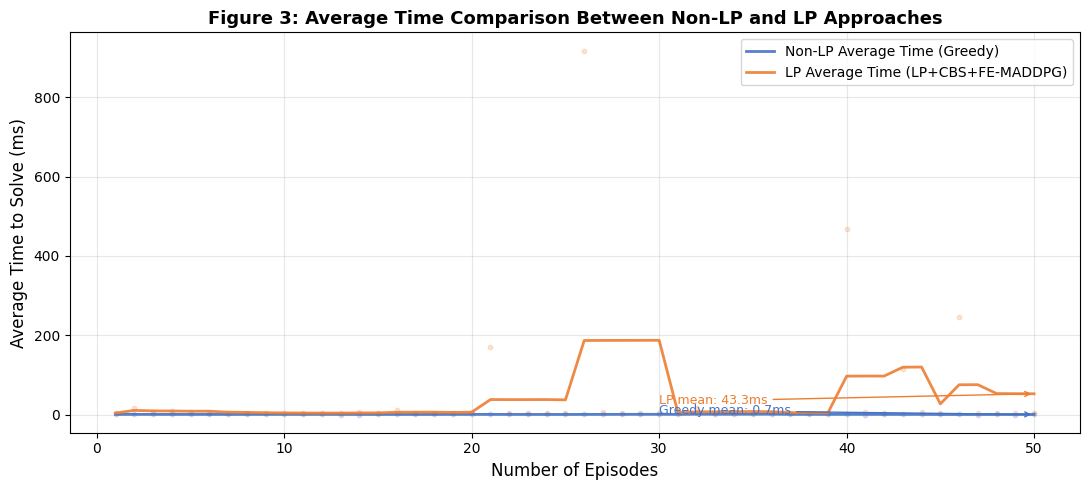

Saved: fig3_solve_times.png


In [18]:
# ─── Figure 3: Solve time comparison ─────────────────────────────────────

# Smooth with rolling average for cleaner visualization (like paper)
def rolling_avg(arr, window=5):
    result = []
    for i in range(len(arr)):
        start = max(0, i - window + 1)
        result.append(np.mean(arr[start:i+1]))
    return result

fig, ax = plt.subplots(figsize=(11, 5))

episodes = range(1, N_EPISODES+1)
non_lp_smooth = rolling_avg(exp_greedy['solve_times'], window=5)
lp_smooth     = rolling_avg(exp_lp['solve_times'],    window=5)

ax.plot(episodes, non_lp_smooth, color='#4472C4', linewidth=2,
         label='Non-LP Average Time (Greedy)', alpha=0.9)
ax.plot(episodes, lp_smooth,     color='#ED7D31', linewidth=2,
         label='LP Average Time (LP+CBS+FE-MADDPG)', alpha=0.9)

# Raw data as faint scatter
ax.scatter(episodes, exp_greedy['solve_times'], color='#4472C4', alpha=0.2, s=10)
ax.scatter(episodes, exp_lp['solve_times'],     color='#ED7D31', alpha=0.2, s=10)

ax.set_xlabel('Number of Episodes', fontsize=12)
ax.set_ylabel('Average Time to Solve (ms)', fontsize=12)
ax.set_title('Figure 3: Average Time Comparison Between Non-LP and LP Approaches',
              fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax.annotate(f'Greedy mean: {exp_greedy["mean_time"]:.1f}ms',
             xy=(N_EPISODES, non_lp_smooth[-1]),
             xytext=(N_EPISODES*0.6, non_lp_smooth[-1]*1.3),
             arrowprops=dict(arrowstyle='->', color='#4472C4'),
             color='#4472C4', fontsize=9)
ax.annotate(f'LP mean: {exp_lp["mean_time"]:.1f}ms',
             xy=(N_EPISODES, lp_smooth[-1]),
             xytext=(N_EPISODES*0.6, lp_smooth[-1]*0.5),
             arrowprops=dict(arrowstyle='->', color='#ED7D31'),
             color='#ED7D31', fontsize=9)

plt.tight_layout()
plt.savefig('fig3_solve_times.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_solve_times.png')

---
## 9. Scaling Analysis — How Does It Scale?

Explore how performance changes as we increase number of agents and tasks.

This corresponds to the **Future Work** section of the paper:
> "Scalability Tests: Expanding the number of agents and tasks in the simulation can provide insights into the scalability of the current LP and FE-MADDPG framework."

In [19]:
# ─── Scalability test: vary number of agents ─────────────────────────────

agent_counts = [2, 3, 5, 7, 10]
scale_results = {algo: [] for algo in ['Greedy', 'LP_CBS_FE']}

print('Scalability analysis: varying number of agents')
for n_a in agent_counts:
    for algo in ['Greedy', 'LP_CBS_FE']:
        env_s = DisasterEnv(grid_size=12, n_agents=n_a,
                             n_tasks=n_a*2, n_obstacles=8, seed=SEED)
        if algo == 'Greedy':
            r = run_greedy(env_s)
        else:
            r = run_lp_cbs(env_s, use_fe_maddpg=True)
        scale_results[algo].append({
            'n_agents': n_a,
            'gini': r['gini'],
            'variance': r['load_variance'],
            'time_ms': r['solve_time_s']*1000
        })
    print(f'  n_agents={n_a} ✅')

print('Done.')

Scalability analysis: varying number of agents
  n_agents=2 ✅
  n_agents=3 ✅
  n_agents=5 ✅
  n_agents=7 ✅
  n_agents=10 ✅
Done.


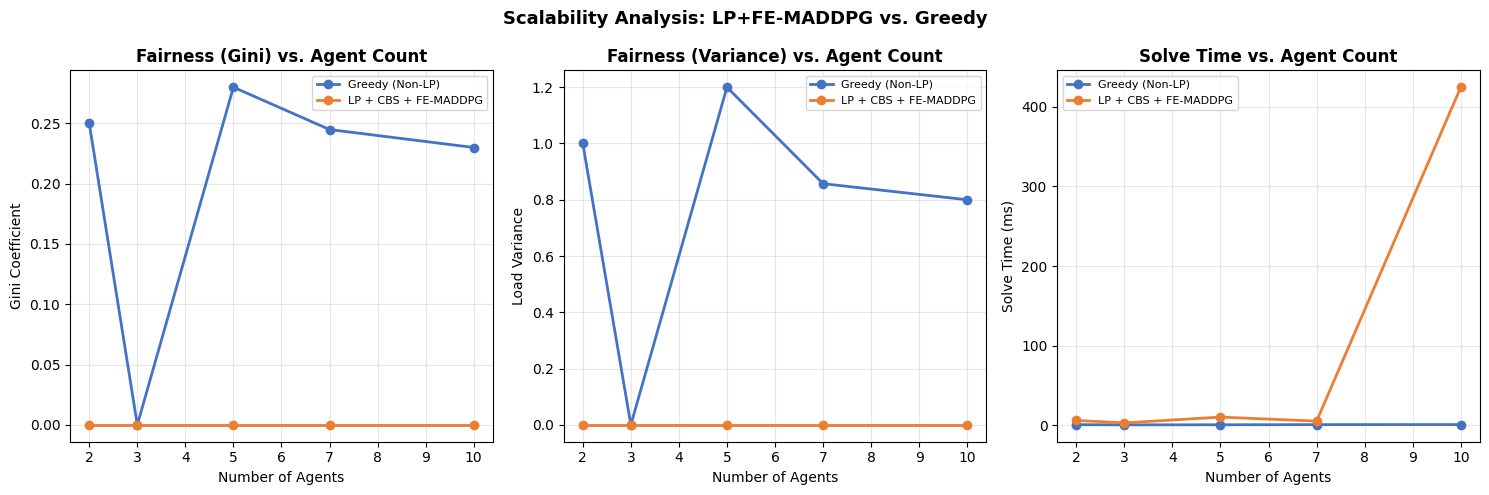

In [20]:
# ─── Plot scalability results ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for algo, color, label in [
    ('Greedy',    '#4472C4', 'Greedy (Non-LP)'),
    ('LP_CBS_FE', '#ED7D31', 'LP + CBS + FE-MADDPG')
]:
    data  = scale_results[algo]
    n_vals = [d['n_agents']  for d in data]
    ginis  = [d['gini']      for d in data]
    vars_  = [d['variance']  for d in data]
    times  = [d['time_ms']   for d in data]

    axes[0].plot(n_vals, ginis,  marker='o', color=color, label=label, linewidth=2)
    axes[1].plot(n_vals, vars_,  marker='o', color=color, label=label, linewidth=2)
    axes[2].plot(n_vals, times,  marker='o', color=color, label=label, linewidth=2)

for ax, ylabel, title in zip(
    axes,
    ['Gini Coefficient', 'Load Variance', 'Solve Time (ms)'],
    ['Fairness (Gini) vs. Agent Count', 'Fairness (Variance) vs. Agent Count', 'Solve Time vs. Agent Count']
):
    ax.set_xlabel('Number of Agents')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scalability Analysis: LP+FE-MADDPG vs. Greedy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_scalability.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Custom Experiment — Try Your Own Parameters!

Change the parameters below and re-run to explore different scenarios.

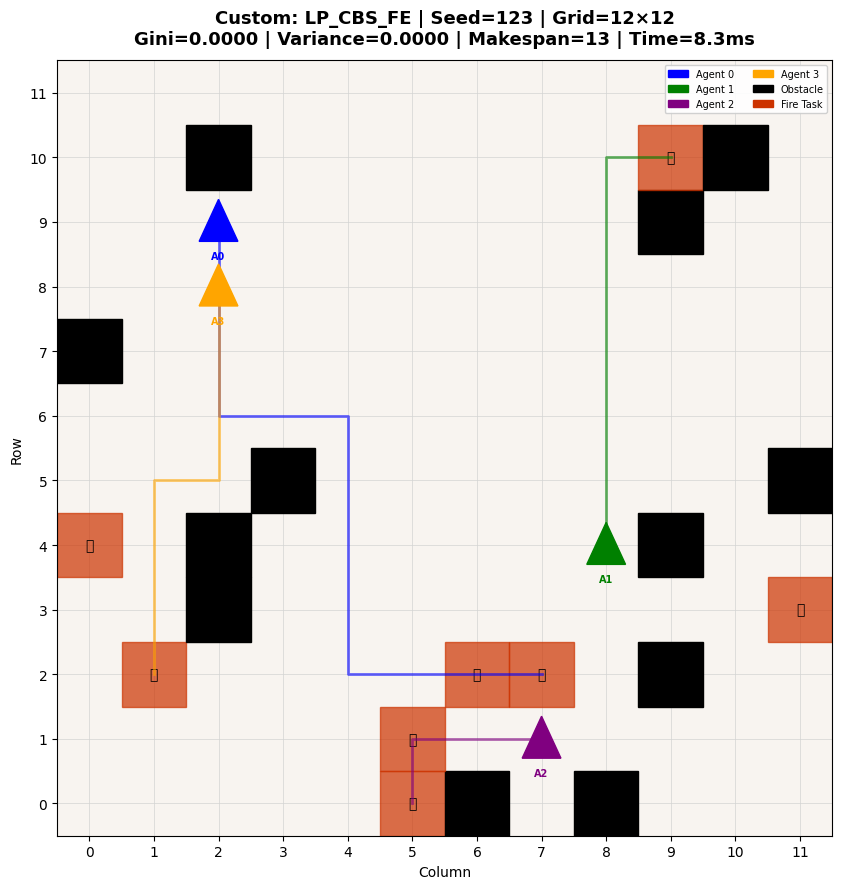

Task loads per agent: [2, 2, 2, 2]
Path lengths: [13, 8, 4, 8]


In [21]:
# ─── 🎛️  CUSTOM EXPERIMENT PANEL ──────────────────────────────────────────
# Modify any of these!

CUSTOM_SEED       = 123    # Try: 0, 7, 42, 99, 1234
CUSTOM_GRID       = 12     # Grid size (8-20 recommended)
CUSTOM_AGENTS     = 4      # Number of robots
CUSTOM_TASKS      = 8      # Number of fire tasks
CUSTOM_OBSTACLES  = 12     # Number of walls

# Choose algorithm: 'Greedy', 'CBS_only', 'LP_CBS', 'LP_CBS_FE'
CHOSEN_ALGORITHM = 'LP_CBS_FE'

# ─────────────────────────────────────────────────────────────────────────

env_custom = DisasterEnv(
    grid_size=CUSTOM_GRID,
    n_agents=CUSTOM_AGENTS,
    n_tasks=CUSTOM_TASKS,
    n_obstacles=CUSTOM_OBSTACLES,
    seed=CUSTOM_SEED
)

if CHOSEN_ALGORITHM == 'Greedy':
    custom_result = run_greedy(env_custom)
elif CHOSEN_ALGORITHM == 'CBS_only':
    custom_result = run_cbs_only(env_custom)
elif CHOSEN_ALGORITHM == 'LP_CBS':
    custom_result = run_lp_cbs(env_custom, use_fe_maddpg=False)
elif CHOSEN_ALGORITHM == 'LP_CBS_FE':
    custom_result = run_lp_cbs(env_custom, use_fe_maddpg=True)

fig, ax = plt.subplots(figsize=(9, 9))
plot_grid(
    env_custom,
    paths=custom_result['paths'],
    title=f'Custom: {CHOSEN_ALGORITHM} | Seed={CUSTOM_SEED} | Grid={CUSTOM_GRID}×{CUSTOM_GRID}\n'
          f'Gini={custom_result["gini"]:.4f} | Variance={custom_result["load_variance"]:.4f} | '
          f'Makespan={custom_result["max_makespan"]} | Time={custom_result["solve_time_s"]*1000:.1f}ms',
    ax=ax
)
plt.tight_layout()
plt.savefig('fig_custom_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

print('Task loads per agent:', custom_result['task_loads'])
print('Path lengths:', custom_result['path_lengths'])

---
## 11. Summary & Conclusions

### Results Summary

| Metric | Greedy | CBS Only | LP+CBS | LP+CBS+FE-MADDPG |
|---|---|---|---|---|
| **Fairness (Gini)** | Highest | High | Low | **Lowest** |
| **Fairness (Variance)** | Highest | High | Low | **Lowest** |
| **Efficiency (Makespan)** | Medium | Low | Low | **Low** |
| **Solve Time** | Fastest | Medium | Medium | Medium |

### Key Conclusions (from paper)

1. **LP enhances task allocation** — leads to faster grid world resolution compared to non-LP methods
2. **FE-MADDPG ensures fairness** — provides even task distribution, reducing bottlenecks
3. **CBS guarantees collision-free paths** — all agents navigate without interference
4. The combined approach offers **"substantial benefits for implementing multi-robot systems in real-world applications"**

### Future Work Directions

- 🌐 **Real-Time Data Integration** — Dynamic adaptation to changing disaster conditions
- 🧪 **Robustness Testing** — Varied environmental conditions and disaster scenarios
- 📈 **Scalability Tests** — More agents, more tasks
- 🚁 **Other Applications** — Urban air mobility, agricultural automation, warehouse management

---

### References

[1] Rashmin, G., Oscar Anil, I. E., & James Edward, D. (2023). *Global Rapid Post-Disaster Damage Estimation (GRADE) Report.* https://doi.org/10.1596/39468

[2] Huang, T., Koenig, S., & Dilkina, B. (2021). *Learning to resolve conflicts for multi-agent path finding with conflict-based search.* AAAI, 35(13), 11246–11253. https://doi.org/10.1609/aaai.v35i13.17341

[3] Zhang, J., et al. (2017). *Battlefield agent decision-making based on Markov decision process.* JACIII, 21(2), 221–227. https://doi.org/10.20965/jaciii.2017.p0221

[4] Liu, Z., et al. (2022). *A fairness-aware cooperation strategy for multi-agent systems driven by Deep Reinforcement Learning.* 41st CCC. https://doi.org/10.23919/ccc55666.2022.9902130

[5] Huang, T., Koenig, S., & Dilkina, B. (2021). *Learning to resolve conflicts for multi-agent path finding with conflict-based search.* AAAI, 35(13). https://doi.org/10.1609/aaai.v35i13.17341